# 09 - Final Analysis, Processed Datasets and Insights
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Run the complete pipeline once more from a single entry point, export every processed dataset for Power BI, and turn the computed results into the insight list.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


## 1. Run the whole pipeline from the shared code

`src/pipeline.py` is the same code the notebooks above use, so the exported files
cannot drift away from what was demonstrated.

In [2]:
import json
import pipeline
import config as C
from IPython.display import display

results = pipeline.run(verbose=True)
print("runtime (seconds):", results["runtime_seconds"])

[1/9] loaded 18,265 rows x 13 cols from Air_quality_data.csv


[2/9] cleaning: 0 rows removed, 0 missing values remain


[3/9] feature engineering: 47 columns


[4/9] statistical + integrity tests done


[5/9] correlation: strongest partner of AQI is PM10 (r=0.2296)


...

[6/9] K-Means: K=2, silhouette=0.0838


[7/9] Isolation Forest: 914 anomalies (5.0%)


[8/9] classification: best macro-F1 Random Forest=0.7765


          extreme-episode flag set on 0 records (0.00%)


[9/9] exported 43 CSVs + results.json (292.6s)
runtime (seconds): 292.6


## 2. Environment recorded for reproducibility

In [3]:
display(pd.DataFrame(list(results["environment"].items()),
                     columns=["Component", "Version / setting"]))

,Component,Version / setting
0,python,3.11.9
1,platform,Windows-10-10.0.26200-SP0
2,pandas,3.0.6
3,numpy,2.4.6
4,sklearn,1.9.1
5,scipy,1.17.1
6,matplotlib,3.11.2
7,random_state,42


## 3. Dataset facts used in the report

In [4]:
ds = results["dataset"]
display(pd.DataFrame(list(ds.items()), columns=["Item", "Value"]))

,Item,Value
0,file,C:\Users\DELL\OneDrive\Desktop\Air Quality\data\raw\Air_quality_data.csv
1,rows,18265
2,columns,13
3,cities,5
4,date_start,2015-01-01
5,date_end,2024-12-31
6,detected_pollutants,"[PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3]"
7,columns_absent_vs_expected,"[Benzene, Toluene, Xylene]"
8,missing_before,0
9,duplicates_before,0


## 4. Every processed dataset that Power BI will import

In [5]:
files = sorted(C.PROCESSED_DIR.glob("*.csv"))
table = pd.DataFrame({
    "file": [f.name for f in files],
    "rows": [sum(1 for _ in open(f, encoding="utf-8")) - 1 for f in files],
    "columns": [pd.read_csv(f, nrows=1).shape[1] for f in files]})
display(table)
print("primary BI inputs:")
for k, v in results["exports"].items():
    print(f"  {k:<22}{Path(v).name}")

,file,rows,columns
0,air_quality_cleaned.csv,18265,40
1,anomaly_by_city.csv,5,4
2,anomaly_by_year.csv,10,4
3,anomaly_pollutant_comparison.csv,9,7
4,anomaly_results.csv,18265,20
5,aqi_bucket_distribution.csv,6,3
6,aqi_driver_selection.csv,3,2
7,aqi_structure_probe.csv,12,3
8,autocorrelation.csv,5,3
9,city_bucket_matrix.csv,5,7


primary BI inputs:
  cleaned               air_quality_cleaned.csv
  city_summary          city_summary.csv
  monthly_summary       monthly_summary.csv
  cluster_results       cluster_results.csv
  anomaly_results       anomaly_results.csv
  classification_resultsclassification_results.csv
  model_comparison      model_comparison.csv
  dim_date              dim_date.csv
  dim_bucket            dim_bucket.csv
  dim_city              dim_city.csv
  insights              insights.csv


## 5. Insights generated from the computed results

Each insight is assembled by `src/reporting.py` from numbers that exist in the
artefacts listed above, and carries its own evidence column and source file.

In [6]:
ins = pd.DataFrame(results["insights"])
display(ins[["Category", "Insight", "Evidence Strength"]])
print("full table with evidence:")
display(ins[["Insight", "Quantitative Evidence", "Derived From"]])

,Category,Insight,Evidence Strength
0,Data scope,"The dataset covers 18,265 daily observations across 5 cities from 2015-01-01 to 2024-1...",measured
1,Data quality,Cleaning removed no rows: the supplied file contains no duplicate records and no missi...,measured
2,City comparison,"Mumbai has the highest average AQI (318.185) and Chennai the lowest (316.619), a gap o...",measured
3,Statistical test,"Although city averages differ slightly, the difference between cities is NOT statistic...",measured
4,Correlation,"PM10 shows the strongest association with AQI (Pearson r=0.2296, weak, p=4.49e-217); 3...",measured
5,Correlation,"Measured linearly, PM10 explains only 5.3% of AQI variance, and correlation is not cau...",measured
6,Clustering,"K-Means was run with K=2, selected because it maximised the silhouette score (0.0838);...",measured
7,Clustering,The silhouette score of 0.0838 is below the conventional 0.25 threshold for meaningful...,measured
8,Anomaly detection,"Isolation Forest flagged 914 of 18,265 records (5.0%) as statistically unusual; Chenna...",measured
9,Anomaly detection,"Anomaly rates differ across cities by only 0.87 percentage points, which is consistent...",measured


full table with evidence:


,Insight,Quantitative Evidence,Derived From
0,"The dataset covers 18,265 daily observations across 5 cities from 2015-01-01 to 2024-1...","rows=18,265; cities=5; range=2015-01-01..2024-12-31",Notebook 01/02 - data quality report
1,Cleaning removed no rows: the supplied file contains no duplicate records and no missi...,"duplicates_before=0, missing_before=0, rows_removed=0",Notebook 02 - cleaning log
2,"Mumbai has the highest average AQI (318.185) and Chennai the lowest (316.619), a gap o...",max_avg_AQI=318.185 (Mumbai); min_avg_AQI=316.619 (Chennai); gap=1.57,city_summary.csv
3,"Although city averages differ slightly, the difference between cities is NOT statistic...","ANOVA_F=0.0985, p=0.983, mean_spread=1.566",Notebook 05 - group comparison test
4,"PM10 shows the strongest association with AQI (Pearson r=0.2296, weak, p=4.49e-217); 3...","top_r=0.2296, r2=0.0527, p=4.49e-217, significant=3/9",correlation_matrix.csv / Notebook 05
5,"Measured linearly, PM10 explains only 5.3% of AQI variance, and correlation is not cau...",r2=0.0527,Notebook 05
6,"K-Means was run with K=2, selected because it maximised the silhouette score (0.0838);...","chosen_K=2, silhouette=0.0838, elbow_K=4",Notebook 06 - K selection table
7,The silhouette score of 0.0838 is below the conventional 0.25 threshold for meaningful...,silhouette=0.0838 < 0.25,Notebook 06 - K selection table
8,"Isolation Forest flagged 914 of 18,265 records (5.0%) as statistically unusual; Chenna...","anomalies=914, share=5.0%, contamination=0.05",anomaly_results.csv
9,"Anomaly rates differ across cities by only 0.87 percentage points, which is consistent...",anomaly_pct_spread=0.87pp,Notebook 07


## 6. Key result tables in one place

In [7]:
display(pd.DataFrame(results["classification"]["comparison"])[
    ["Model", "Accuracy_%", "F1_macro", "Lift_over_Baseline_pp"]].head())
display(pd.DataFrame(results["clustering"]["choice"], index=["value"]).T)
display(pd.DataFrame([results["anomaly"]["stats"]]))
display(pd.DataFrame([results["predictability"]]))
display(pd.DataFrame([results["trend_test"]]))

,Model,Accuracy_%,F1_macro,Lift_over_Baseline_pp
0,Random Forest,99.28,0.7765,69.17
1,Decision Tree,94.94,0.7153,64.83
2,Hist Gradient Boosting,89.69,0.6224,59.58
3,Logistic Regression,31.55,0.2491,1.44
4,Baseline (prior),30.11,0.0771,0.00


,value
K_by_silhouette,2
silhouette,0.0838
K_by_elbow_rule,4
elbow_rule,first K where inertia improvement < 5%
chosen_K,2
rationale,"silhouette preferred; the elbow rule suggested a different K, which is reported as a d..."


,Rows evaluated,Anomalies detected,Anomaly %,Configured contamination,Note
0,18265,914,5.0,0.05,"the detected share follows the contamination parameter; it is an assumed sensitivity, ..."


,target,n,features,tree_CV_R2,tree_CV_MAE,linear_R2,gap,verdict
0,AQI,18265,"[PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3]",0.9969,1.2114,0.0579,0.939,the relationship is largely NON-LINEAR: a tree ensemble explains far more than linear ...


,series,n,slope_per_year,p_value,r,significant,verdict
0,AQI,18265,0.0366,0.9001,0.0009,False,no statistically detectable trend


## 7. Final quality check

Every line below is evaluated from the artefacts, not asserted. Two checks deserve
an explanation:

* **Measured columns** (city, date, the nine pollutant concentrations, AQI) must
  contain no blank cells at all.
* **Derived columns** are *allowed* to be blank where the derivation is undefined:
  a ratio whose denominator is zero, and the first day of each city's lag / rolling
  window, which has no previous observation to compare with. Those blanks are
  documented, not silently filled.

In [8]:
import data_utils as U

cleaned = pd.read_csv(C.CLEANED_CSV)
measured = ([C.CITY_COL, "Date"]
            + C.pollutant_columns(cleaned.columns)
            + [c for c in (C.AQI_COL, C.TARGET_COL) if c in cleaned.columns])
blank_cols = set(cleaned.columns[cleaned.isna().any()])
allowed_blank = {"PM25_PM10_Ratio", "NO2_NOx_Ratio", "O3_PM10_Ratio",
                 "AQI_Rolling_7", "AQI_Rolling_30", "AQI_Change_1d",
                 "Cluster_Description", "City_Pollutant_Percentile"}
# Rebuild the category from the AQI value with the single band table in
# src/config.py (through U.band_from_aqi), then count how often it agrees with
# the supplied label - this is the leakage test and the scale test at once.
expected_bucket = U.band_from_aqi(cleaned[C.AQI_COL])
bucket_agreement = float((expected_bucket.astype(str)
                          == cleaned[C.TARGET_COL].astype(str)).mean())
checks = {
 "raw dataset loads": C.RAW_FILE.exists(),
 "cleaned dataset exported": C.CLEANED_CSV.exists(),
 "city summary exported": C.CITY_SUMMARY_CSV.exists(),
 "monthly summary exported": C.MONTHLY_SUMMARY_CSV.exists(),
 "cluster results exported": C.CLUSTER_RESULTS_CSV.exists(),
 "anomaly results exported": C.ANOMALY_RESULTS_CSV.exists(),
 "classification results exported": C.CLASSIFICATION_CSV.exists(),
 "model comparison exported": C.MODEL_COMPARISON_CSV.exists(),
 "insights exported": C.INSIGHTS_CSV.exists(),
 "date / bucket / city dimensions exported":
     C.DIM_DATE_CSV.exists() and C.DIM_BUCKET_CSV.exists() and C.DIM_CITY_CSV.exists(),
 "results.json written": (C.PROCESSED_DIR / "results.json").exists(),
 "no blank cells in the measured columns":
     int(cleaned[measured].isna().sum().sum()) == 0,
 "blank cells confined to documented derived columns": bool(blank_cols <= allowed_blank),
 "one record per city-day":
     not cleaned.duplicated([C.CITY_COL, "Date"]).any(),
 "AQI_Bucket is reproducible from AQI (leakage confirmed)": bucket_agreement == 1.0,
}
display(pd.DataFrame(list(checks.items()), columns=["Check", "Passed"]))
print("all checks passed:", all(checks.values()))
print()
print("blank cells by column (only derived columns may appear):")
blanks = cleaned.isna().sum()
display(blanks[blanks > 0].rename("Blank cells").to_frame())
print(f"AQI_Bucket agreement with the band table: {100 * bucket_agreement:.2f}%")
print("disagreements:", int((expected_bucket.astype(str)
                            != cleaned[C.TARGET_COL].astype(str)).sum()))

,Check,Passed
0,raw dataset loads,True
1,cleaned dataset exported,True
2,city summary exported,True
3,monthly summary exported,True
4,cluster results exported,True
5,anomaly results exported,True
6,classification results exported,True
7,model comparison exported,True
8,insights exported,True
9,date / bucket / city dimensions exported,True


all checks passed: True

blank cells by column (only derived columns may appear):


,Blank cells
PM25_PM10_Ratio,2
NO2_NOx_Ratio,1
AQI_Change_1d,5


AQI_Bucket agreement with the band table: 100.00%
disagreements: 0


## 8. Star-schema tables for Power BI

`FACT_AirQuality` is `air_quality_cleaned.csv`; the three dimension tables below
are what a clean model needs (see `dashboard/POWER_BI_BUILD_GUIDE.md`).

In [9]:
print("DIM_Date rows:", f"{pd.read_csv(C.DIM_DATE_CSV).shape[0]:,}")
display(pd.read_csv(C.DIM_BUCKET_CSV))
display(pd.read_csv(C.DIM_CITY_CSV))

DIM_Date rows: 3,653


,AQI_Bucket,Sort_Order,Band_Lower_AQI,Band_Upper_AQI,Observed_Min_AQI,Observed_Max_AQI,Record_Count,Share_%,Colour
0,Severe,1,401,500,401.0,500.0,5258,28.79,#7E0023
1,Very Poor,2,301,400,301.0,400.0,5501,30.12,#F44336
2,Poor,3,201,300,201.0,300.0,3129,17.13,#FF9800
3,Moderate,4,101,200,101.0,200.0,4258,23.31,#FFFF00
4,Satisfactory,5,51,100,51.0,99.9,113,0.62,#8BC34A
5,Good,6,0,50,26.9,49.2,6,0.03,#00E400


,City,Record_Count,Distinct_Days,First_Observation,Last_Observation,Dominant_Cluster
0,Bangalore,3653,3653,2015-01-01,2024-12-31,0
1,Chennai,3653,3653,2015-01-01,2024-12-31,1
2,Delhi,3653,3653,2015-01-01,2024-12-31,0
3,Kolkata,3653,3653,2015-01-01,2024-12-31,1
4,Mumbai,3653,3653,2015-01-01,2024-12-31,1


## 9. Handoff to Power BI

The CSVs in `data/processed/` are the only inputs the dashboard needs. The star
schema, the DAX measures and the page-by-page build instructions live in
`dashboard/` - see `dashboard/POWER_BI_BUILD_GUIDE.md`.

In [10]:
print("Import these into Power BI Desktop:")
for name in ["air_quality_cleaned.csv", "dim_date.csv", "dim_city.csv",
             "dim_bucket.csv", "city_summary.csv", "monthly_summary.csv",
             "cluster_results.csv", "cluster_profile.csv",
             "anomaly_results.csv", "aqi_bucket_distribution.csv",
             "model_comparison.csv", "classification_per_class.csv",
             "correlation_with_aqi.csv", "insights.csv",
             "data_quality_report.csv", "k_selection_table.csv"]:
    p = C.PROCESSED_DIR / name
    print(f"  {'OK  ' if p.exists() else 'MISS'} {name}")

Import these into Power BI Desktop:
  OK   air_quality_cleaned.csv
  OK   dim_date.csv
  OK   dim_city.csv
  OK   dim_bucket.csv
  OK   city_summary.csv
  OK   monthly_summary.csv
  OK   cluster_results.csv
  OK   cluster_profile.csv
  OK   anomaly_results.csv
  OK   aqi_bucket_distribution.csv
  OK   model_comparison.csv
  OK   classification_per_class.csv
  OK   correlation_with_aqi.csv
  OK   insights.csv
  OK   data_quality_report.csv
  OK   k_selection_table.csv


## 10. Methodology diagram (figure used in the report)

The chain below is the method this project actually followed, stage by stage, and
the italic line under each stage names the file that evidences it - so the
diagram can be checked against `data/processed/` rather than taken on trust.

written to: visualizations\methodology\01_methodology_diagram.png


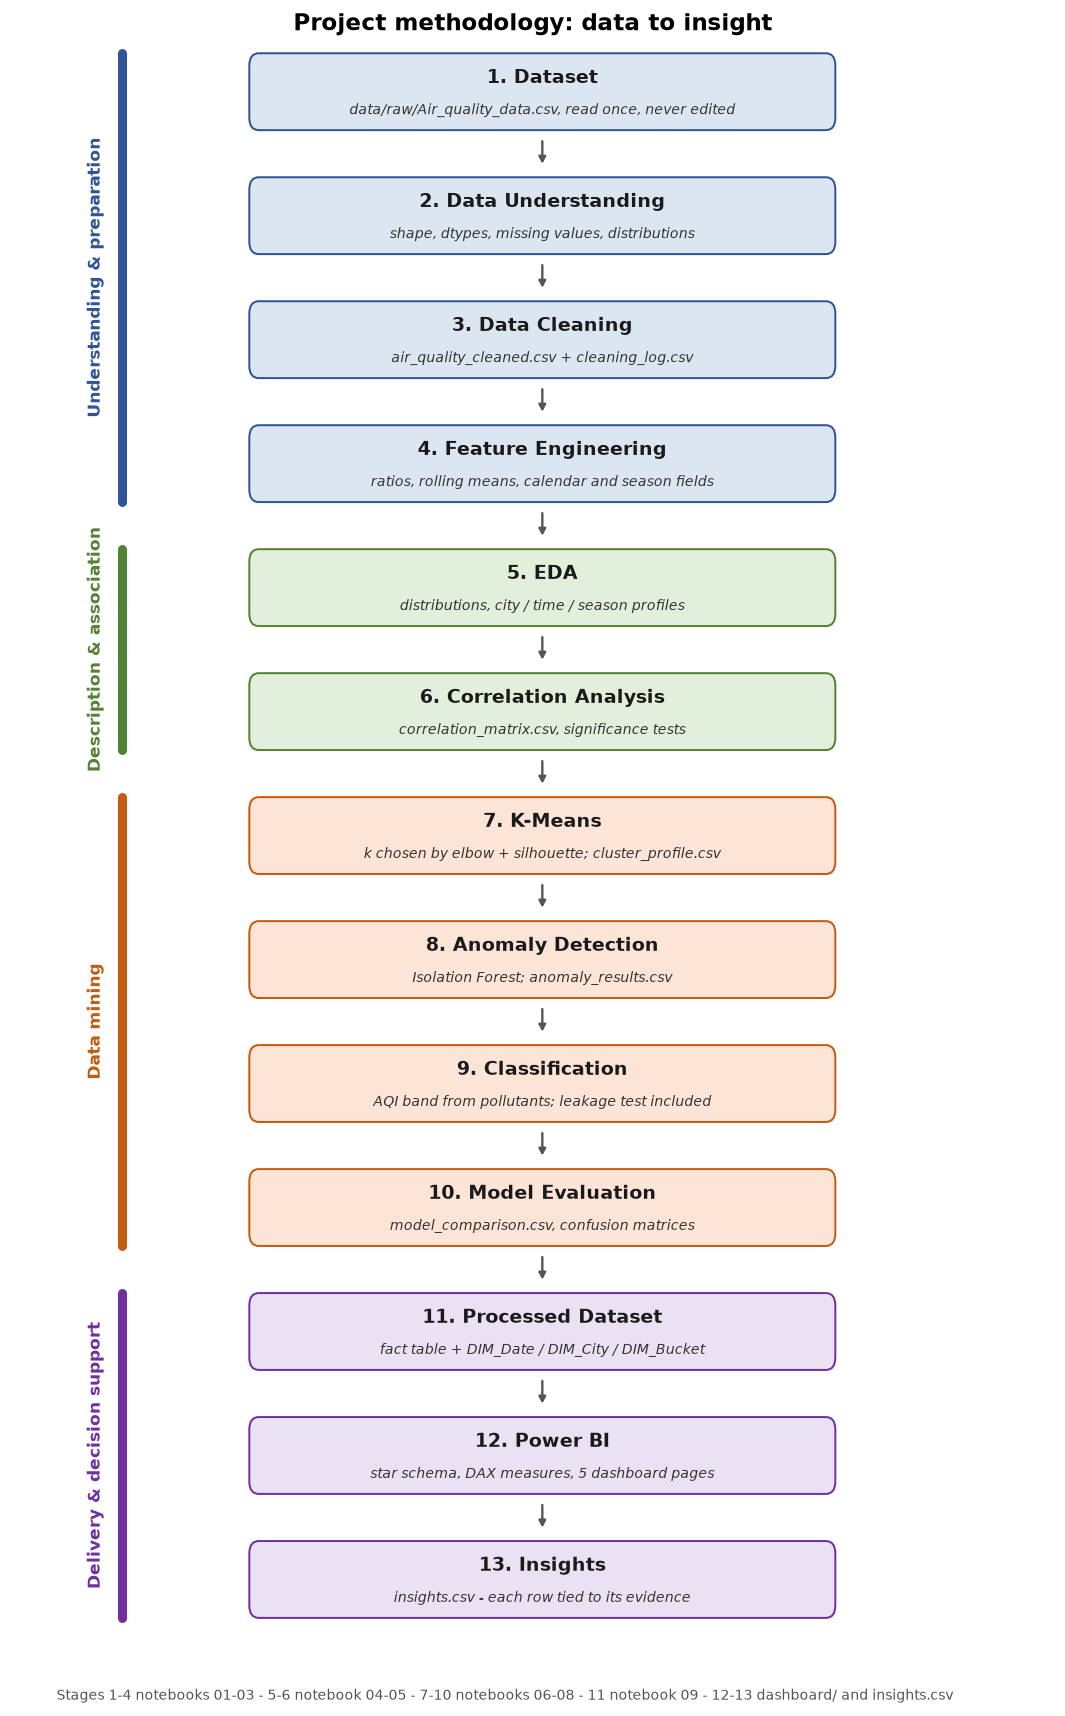

In [11]:
import figures as F
from IPython.display import Image

method_png = F.methodology_diagram()
print("written to:", Path(method_png).relative_to(C.PROJECT_ROOT))
Image(filename=method_png)